# Generating random data

This section generates a synthetic dataset of 1000 suppliers, complete with various performance metrics such as lead time, on-time delivery percentage, defect rate, and risk scores. This simulated data serves as the foundation for the subsequent supplier evaluation and analysis.

In [11]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "Supplier_ID": range(1, n+1),
    "Product_Category": np.random.choice(
        ["Electronics", "Apparel", "Food", "Furniture", "Pharma"], n
    ),
    "Lead_Time_Days": np.random.randint(2, 25, n),
    "On_Time_Delivery_%": np.random.uniform(70, 100, n).round(2),
    "Defect_Rate_%": np.random.uniform(0.5, 8, n).round(2),
    "Price_Variance_%": np.random.uniform(-10, 15, n).round(2),
    "Order_Quantity": np.random.randint(50, 5000, n),
    "Distance_KM": np.random.randint(10, 2000, n),
    "Supplier_Risk_Score": np.random.uniform(1, 10, n).round(2)
})

# ensure no nulls (safety check)
df = df.fillna(0)

df.head()

,Supplier_ID,Product_Category,Lead_Time_Days,On_Time_Delivery_%,Defect_Rate_%,Price_Variance_%,Order_Quantity,Distance_KM,Supplier_Risk_Score
0,1,Furniture,13,75.05,7.39,4.92,4441,118,8.94
1,2,Pharma,13,89.28,3.22,2.54,2209,1899,9.63
2,3,Food,5,92.78,5.94,14.40,3298,1217,2.73
3,4,Pharma,17,85.01,7.21,7.09,3781,1984,7.46
4,5,Pharma,5,86.27,3.92,-0.61,3879,1401,6.98


# Converting raw data into decision-ready supplier metrics

Here, the raw data generated in the previous step is transformed into a set of decision-ready Key Performance Indicators (KPIs). This involves basic data validation (checking for nulls and duplicates) and the engineering of new scores (Delivery, Quality, Cost, Logistics, and Risk-Adjusted Scores). These scores are then normalized to a 0-100 scale for consistent evaluation.

In [12]:
# Basic validation
print(df.info())
print(df.describe())

# Check duplicates
print("Duplicates:", df.duplicated().sum())

# KPI Engineering (core of your project)

df["Delivery_Score"] = df["On_Time_Delivery_%"]

df["Quality_Score"] = 100 - (df["Defect_Rate_%"] * 10)

df["Cost_Score"] = 100 - (df["Price_Variance_%"].abs() * 5)

df["Logistics_Score"] = 100 - (df["Distance_KM"] / 50)

df["Risk_Adjusted_Score"] = 100 - (df["Supplier_Risk_Score"] * 10)

# Normalize bounds (important)
score_cols = [
    "Delivery_Score",
    "Quality_Score",
    "Cost_Score",
    "Logistics_Score",
    "Risk_Adjusted_Score"
]

for col in score_cols:
    df[col] = df[col].clip(0, 100)

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Supplier_ID          1000 non-null   int64  
 1   Product_Category     1000 non-null   object 
 2   Lead_Time_Days       1000 non-null   int64  
 3   On_Time_Delivery_%   1000 non-null   float64
 4   Defect_Rate_%        1000 non-null   float64
 5   Price_Variance_%     1000 non-null   float64
 6   Order_Quantity       1000 non-null   int64  
 7   Distance_KM          1000 non-null   int64  
 8   Supplier_Risk_Score  1000 non-null   float64
dtypes: float64(4), int64(4), object(1)
memory usage: 70.4+ KB
None
       Supplier_ID  Lead_Time_Days  On_Time_Delivery_%  Defect_Rate_%  \
count  1000.000000     1000.000000         1000.000000    1000.000000   
mean    500.500000       13.031000           84.779440       4.390210   
std     288.819436        6.647874            8.617586    

,Supplier_ID,Product_Category,Lead_Time_Days,On_Time_Delivery_%,Defect_Rate_%,Price_Variance_%,Order_Quantity,Distance_KM,Supplier_Risk_Score,Delivery_Score,Quality_Score,Cost_Score,Logistics_Score,Risk_Adjusted_Score
0,1,Furniture,13,75.05,7.39,4.92,4441,118,8.94,75.05,26.1,75.40,97.64,10.6
1,2,Pharma,13,89.28,3.22,2.54,2209,1899,9.63,89.28,67.8,87.30,62.02,3.7
2,3,Food,5,92.78,5.94,14.40,3298,1217,2.73,92.78,40.6,28.00,75.66,72.7
3,4,Pharma,17,85.01,7.21,7.09,3781,1984,7.46,85.01,27.9,64.55,60.32,25.4
4,5,Pharma,5,86.27,3.92,-0.61,3879,1401,6.98,86.27,60.8,96.95,71.98,30.2


# Weighted Supplier Score + Ranking

Converting KPIs into a single decision score

This section calculates an initial overall 'Supplier Final Score' by applying predefined weights to the engineered KPIs. The suppliers are then ranked based on this score. Additionally, suppliers are segmented into categories like 'Low Performer', 'Medium Performer', and 'Top Performer' to provide a high-level overview of their performance tiers.

In [13]:
# Define weights (you can justify these in your report)
weights = {
    "Delivery_Score": 0.30,
    "Quality_Score": 0.25,
    "Cost_Score": 0.15,
    "Logistics_Score": 0.10,
    "Risk_Adjusted_Score": 0.20
}

# Compute final score
df["Supplier_Final_Score"] = (
    df["Delivery_Score"] * weights["Delivery_Score"] +
    df["Quality_Score"] * weights["Quality_Score"] +
    df["Cost_Score"] * weights["Cost_Score"] +
    df["Logistics_Score"] * weights["Logistics_Score"] +
    df["Risk_Adjusted_Score"] * weights["Risk_Adjusted_Score"]
)

# Ranking suppliers
df["Rank"] = df["Supplier_Final_Score"].rank(ascending=False)

# Supplier segmentation
df["Category"] = pd.cut(
    df["Supplier_Final_Score"],
    bins=[0, 60, 80, 100],
    labels=["Low Performer", "Medium Performer", "Top Performer"]
)

df.sort_values("Supplier_Final_Score", ascending=False).head()

,Supplier_ID,Product_Category,Lead_Time_Days,On_Time_Delivery_%,Defect_Rate_%,Price_Variance_%,Order_Quantity,Distance_KM,Supplier_Risk_Score,Delivery_Score,Quality_Score,Cost_Score,Logistics_Score,Risk_Adjusted_Score,Supplier_Final_Score,Rank,Category
176,177,Food,21,90.23,0.89,-1.60,240,595,1.71,90.23,91.1,92.00,88.10,82.9,89.0340,1.0,Top Performer
975,976,Furniture,14,97.21,0.95,0.85,4225,819,3.11,97.21,90.5,95.75,83.62,68.9,88.2925,2.0,Top Performer
64,65,Apparel,22,97.18,1.35,1.04,1241,1243,2.13,97.18,86.5,94.80,75.14,78.7,88.2530,3.0,Top Performer
138,139,Apparel,23,99.44,1.54,3.86,1565,1037,1.45,99.44,84.6,80.70,79.26,85.5,88.1130,4.0,Top Performer
808,809,Electronics,5,81.90,0.82,1.75,4761,504,1.59,81.90,91.8,91.25,89.92,84.1,87.0195,5.0,Top Performer


# Export + Visual analysis layer
Turning raw scoring into insights + dashboard-ready output.

This part of the notebook focuses on making the scoring data accessible and interpretable. It exports the processed supplier data into a CSV file, suitable for external tools like Power BI or Excel. It also includes basic visualizations such as a histogram of supplier scores, a bar chart of the top 10 suppliers, and a comparison of average scores by supplier category, offering immediate insights into the dataset.

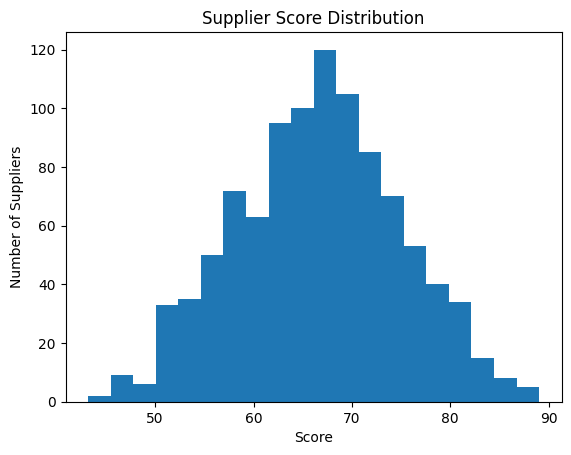

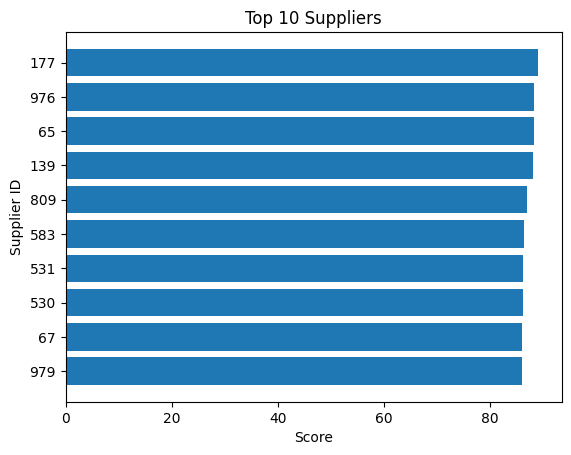

/tmp/ipykernel_754/179250836.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_avg = df.groupby("Category")["Supplier_Final_Score"].mean()


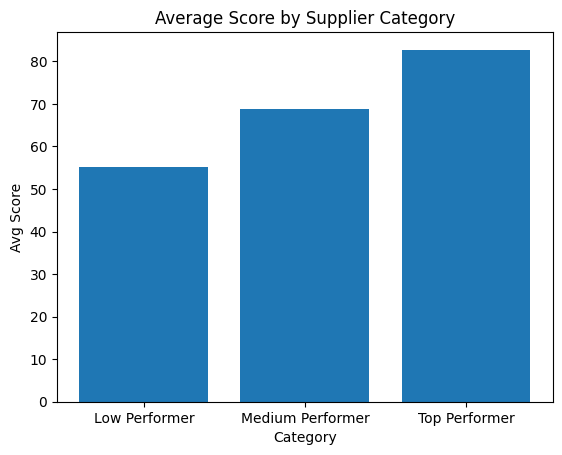

In [14]:
import matplotlib.pyplot as plt

# 1. Export clean dataset for Power BI / Excel
df.to_csv("supplier_scorecard_output.csv", index=False)

# 2. Distribution of supplier scores
plt.figure()
plt.hist(df["Supplier_Final_Score"], bins=20)
plt.title("Supplier Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Suppliers")
plt.show()

# 3. Top 10 suppliers
top10 = df.sort_values("Supplier_Final_Score", ascending=False).head(10)

plt.figure()
plt.barh(top10["Supplier_ID"].astype(str), top10["Supplier_Final_Score"])
plt.title("Top 10 Suppliers")
plt.xlabel("Score")
plt.ylabel("Supplier ID")
plt.gca().invert_yaxis()
plt.show()

# 4. Category performance comparison
category_avg = df.groupby("Category")["Supplier_Final_Score"].mean()

plt.figure()
plt.bar(category_avg.index.astype(str), category_avg.values)
plt.title("Average Score by Supplier Category")
plt.xlabel("Category")
plt.ylabel("Avg Score")
plt.show()

# AHP Weighting
Instead of guessing weights, we derive them using pairwise comparison logic (AHP) (Analytic Hierarchy Process)

This section introduces the Analytic Hierarchy Process (AHP) as a more systematic method for determining the weights of the evaluation criteria. Instead of arbitrary weights, AHP uses pairwise comparisons of criteria (Delivery, Quality, Cost, Logistics, Risk) to derive a set of objective, data-driven weights. This approach aims to bring more rigor and justification to the weighting process.

In [15]:
import numpy as np

criteria = [
    "Delivery",
    "Quality",
    "Cost",
    "Logistics",
    "Risk"
]

# Pairwise comparison matrix (scale 1–9)
# Adjusted to reflect typical procurement priorities
A = np.array([
    [1,   2,   3,   4,   2],
    [1/2, 1,   2,   3,   2],
    [1/3, 1/2, 1,   2,   2],
    [1/4, 1/3, 1/2, 1,   1/2],
    [1/2, 1/2, 1/2, 2,   1]
])

# Normalize
col_sum = A.sum(axis=0)
norm_matrix = A / col_sum

# Priority vector (weights)
weights = norm_matrix.mean(axis=1)

weights_dict = dict(zip(criteria, weights))
weights_dict

{'Delivery': np.float64(0.3754413328606877),
 'Quality': np.float64(0.24533971404939145),
 'Cost': np.float64(0.1641214699279215),
 'Logistics': np.float64(0.07902516838000709),
 'Risk': np.float64(0.13607231478199217)}

# Recalculating final score

Using the AHP-derived weights from the previous section, the 'Supplier Final Score' is re-calculated. This provides an alternative, potentially more robust, ranking of suppliers based on a more analytically determined weighting scheme. The new scores and ranks are stored in `Supplier_Final_Score_AHP` and `Rank_AHP` respectively.

In [16]:
df["Supplier_Final_Score_AHP"] = (
    df["Delivery_Score"] * weights_dict["Delivery"] +
    df["Quality_Score"] * weights_dict["Quality"] +
    df["Cost_Score"] * weights_dict["Cost"] +
    df["Logistics_Score"] * weights_dict["Logistics"] +
    df["Risk_Adjusted_Score"] * weights_dict["Risk"]
)

df["Rank_AHP"] = df["Supplier_Final_Score_AHP"].rank(ascending=False)

df.sort_values("Supplier_Final_Score_AHP", ascending=False).head()

,Supplier_ID,Product_Category,Lead_Time_Days,On_Time_Delivery_%,Defect_Rate_%,Price_Variance_%,Order_Quantity,Distance_KM,Supplier_Risk_Score,Delivery_Score,Quality_Score,Cost_Score,Logistics_Score,Risk_Adjusted_Score,Supplier_Final_Score,Rank,Category,Supplier_Final_Score_AHP,Rank_AHP
975,976,Furniture,14,97.21,0.95,0.85,4225,819,3.11,97.21,90.5,95.75,83.62,68.9,88.2925,2.0,Top Performer,90.397994,1.0
64,65,Apparel,22,97.18,1.35,1.04,1241,1243,2.13,97.18,86.5,94.80,75.14,78.7,88.2530,3.0,Top Performer,89.912832,2.0
176,177,Food,21,90.23,0.89,-1.60,240,595,1.71,90.23,91.1,92.00,88.10,82.9,89.0340,1.0,Top Performer,89.568207,3.0
138,139,Apparel,23,99.44,1.54,3.86,1565,1037,1.45,99.44,84.6,80.70,79.26,85.5,88.1130,4.0,Top Performer,89.231946,4.0
582,583,Electronics,3,98.40,1.38,-0.55,1530,1398,3.27,98.40,86.2,97.25,72.04,67.3,86.3215,6.0,Top Performer,88.903163,5.0


# Sensitivity analysis

This section performs a sensitivity analysis to assess how different strategic priorities (represented by varying weights) affect supplier rankings. A 'Cost-Heavy Score' is introduced, where cost criteria are given a higher weighting. By comparing this new score with the AHP-derived score, we can understand the impact of strategic shifts on supplier performance evaluation.

In [17]:
df["Cost_Heavy_Score"] = (
    df["Delivery_Score"] * 0.20 +
    df["Quality_Score"] * 0.20 +
    df["Cost_Score"] * 0.35 +
    df["Logistics_Score"] * 0.10 +
    df["Risk_Adjusted_Score"] * 0.15
)

comparison = pd.DataFrame({
    "AHP_Score": df["Supplier_Final_Score_AHP"],
    "Cost_Heavy_Score": df["Cost_Heavy_Score"]
})

comparison.corr()

,AHP_Score,Cost_Heavy_Score
AHP_Score,1.00000,0.89373
Cost_Heavy_Score,0.89373,1.00000


# Risk stress simulation
Simulate disruption in suppliers

This section simulates potential supply chain disruptions, specifically focusing on lead time delays, to evaluate supplier resilience under stress. A 'Simulated Delay' is introduced, and a 'Stress Score' is calculated to identify suppliers that might be more vulnerable in adverse conditions, providing insights for risk mitigation strategies.

In [18]:
df["Simulated_Delay"] = df["Lead_Time_Days"] * np.random.normal(1.2, 0.2, len(df))

df["Stress_Score"] = (
    df["Delivery_Score"] * 0.25 +
    df["Quality_Score"] * 0.25 +
    (100 - df["Simulated_Delay"]) * 0.25 +
    df["Risk_Adjusted_Score"] * 0.25
)

df.sort_values("Stress_Score", ascending=False).head()

,Supplier_ID,Product_Category,Lead_Time_Days,On_Time_Delivery_%,Defect_Rate_%,Price_Variance_%,Order_Quantity,Distance_KM,Supplier_Risk_Score,Delivery_Score,...,Logistics_Score,Risk_Adjusted_Score,Supplier_Final_Score,Rank,Category,Supplier_Final_Score_AHP,Rank_AHP,Cost_Heavy_Score,Simulated_Delay,Stress_Score
209,210,Furniture,10,96.28,1.07,5.49,2989,1887,1.50,96.28,...,62.26,85.0,85.3175,11.0,Top Performer,86.449594,11.0,81.4845,11.234538,89.836365
529,530,Pharma,13,94.84,1.04,-6.47,4322,957,1.48,94.84,...,80.86,85.2,86.1255,8.0,Top Performer,86.675448,9.0,81.4315,11.802478,89.459381
705,706,Furniture,3,82.38,1.08,9.91,2380,406,1.23,82.38,...,91.88,87.7,81.3095,40.0,Top Performer,80.287462,80.0,74.3165,2.964045,89.078989
601,602,Furniture,4,92.72,2.11,-9.30,4268,1106,1.45,92.72,...,77.88,85.5,80.4540,50.0,Top Performer,80.737385,73.0,73.6620,4.440798,88.169801
808,809,Electronics,5,81.90,0.82,1.75,4761,504,1.59,81.90,...,89.92,84.1,87.0195,5.0,Top Performer,86.796540,8.0,88.2845,5.460061,88.084985


I built a supplier evaluation system combining AHP-based multi-criteria decision making, sensitivity analysis under different procurement strategies, and stress testing under supply chain disruptions to simulate real-world volatility

Preparing dataset to work on PowerBI

This final section is dedicated to preparing the complete dataset for further analysis and visualization in business intelligence tools like Power BI. All engineered features, scores, and rankings, including those from the AHP and stress simulations, are consolidated and exported to a CSV file named `supplier_scorecard_final.csv`. This ensures that all the developed insights are available for dashboard creation and detailed reporting.

In [19]:
df.to_csv("supplier_scorecard_final.csv", index=False)

## Advanced Visualizations

This section provides additional visualizations that leverage the more advanced analyses performed, such as AHP-derived weights, sensitivity analysis, and stress simulations. These plots offer deeper insights into the supplier data and the impact of different evaluation methodologies.

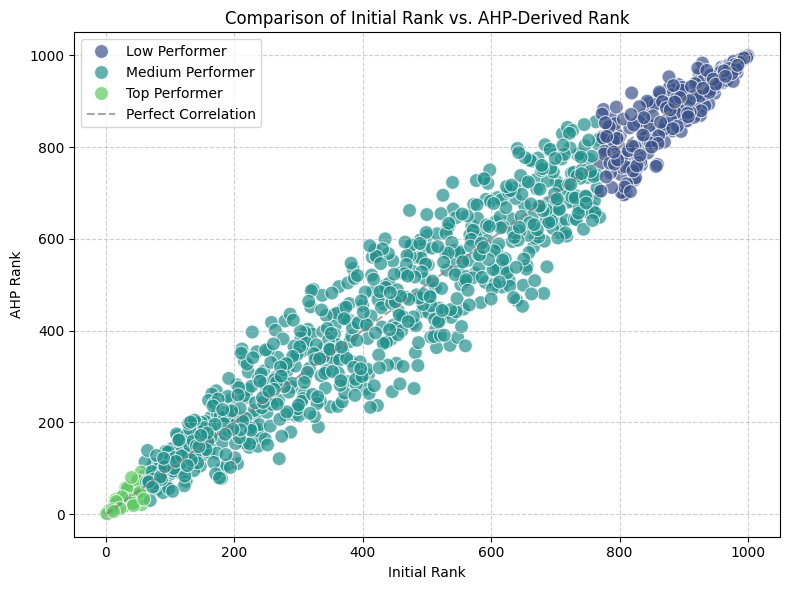

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Comparison of Initial Rank vs. AHP-Derived Rank
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Rank', y='Rank_AHP', data=df, hue='Category', palette='viridis', s=100, alpha=0.7)
plt.plot([1, df['Rank'].max()], [1, df['Rank'].max()], linestyle='--', color='gray', alpha=0.7, label='Perfect Correlation')
plt.title('Comparison of Initial Rank vs. AHP-Derived Rank')
plt.xlabel('Initial Rank')
plt.ylabel('AHP Rank')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

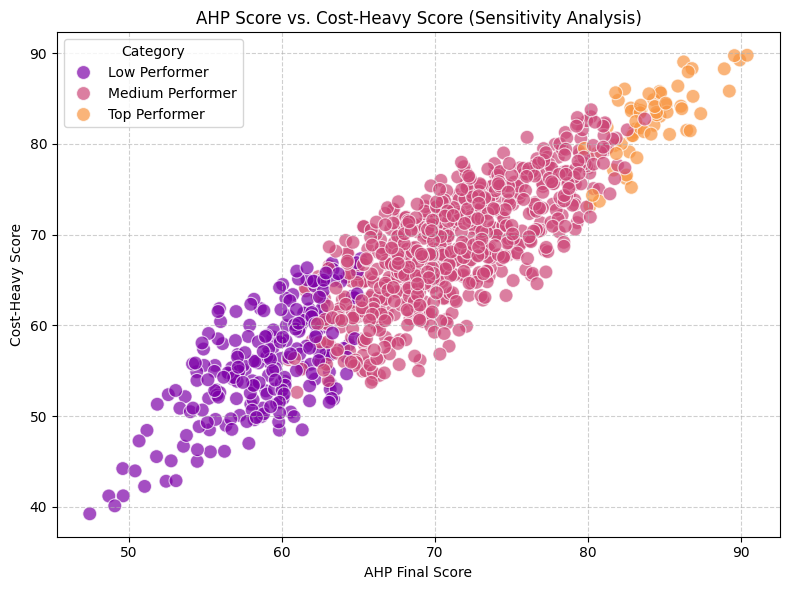

In [22]:
# 2. Sensitivity Analysis: AHP Score vs. Cost-Heavy Score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Supplier_Final_Score_AHP', y='Cost_Heavy_Score', data=df, hue='Category', palette='plasma', s=100, alpha=0.7)
plt.title('AHP Score vs. Cost-Heavy Score (Sensitivity Analysis)')
plt.xlabel('AHP Final Score')
plt.ylabel('Cost-Heavy Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

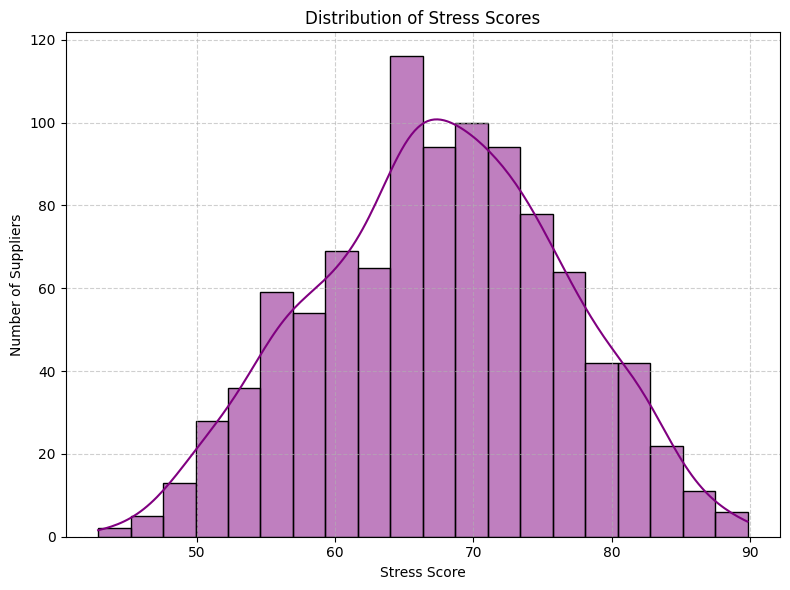

In [23]:
# 3. Distribution of Stress Scores
plt.figure(figsize=(8, 6))
sns.histplot(df['Stress_Score'], bins=20, kde=True, color='purple')
plt.title('Distribution of Stress Scores')
plt.xlabel('Stress Score')
plt.ylabel('Number of Suppliers')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

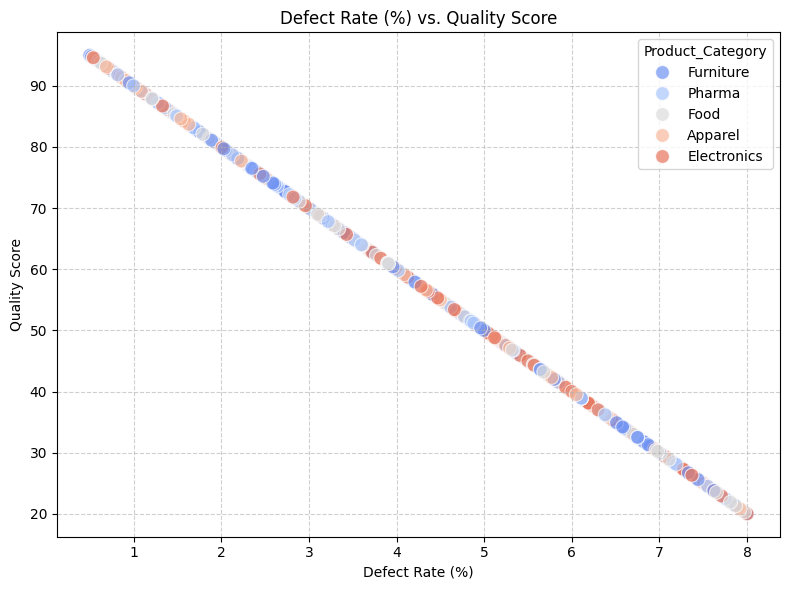

In [24]:
# 4. Relationship between Defect Rate and Quality Score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Defect_Rate_%', y='Quality_Score', data=df, hue='Product_Category', palette='coolwarm', s=100, alpha=0.7)
plt.title('Defect Rate (%) vs. Quality Score')
plt.xlabel('Defect Rate (%)')
plt.ylabel('Quality Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

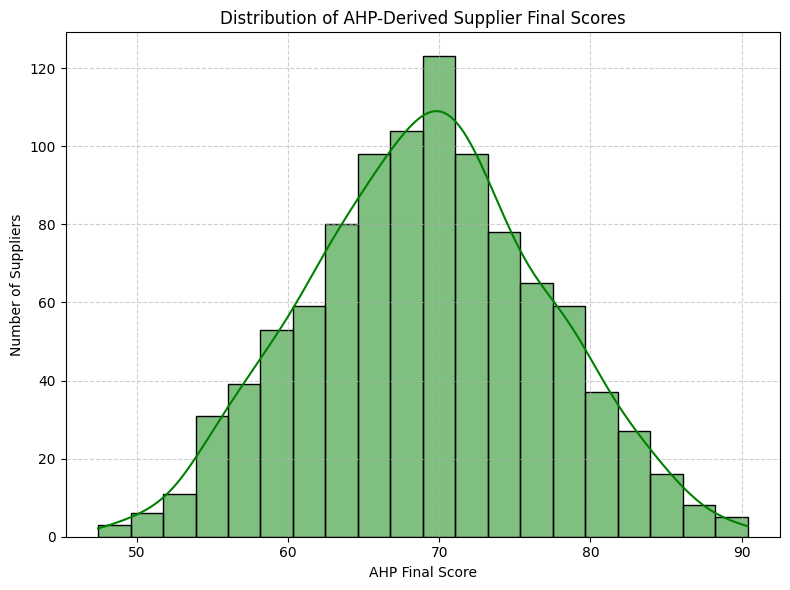

In [25]:
# 5. Distribution of AHP-Derived Supplier Final Scores
plt.figure(figsize=(8, 6))
sns.histplot(df['Supplier_Final_Score_AHP'], bins=20, kde=True, color='green')
plt.title('Distribution of AHP-Derived Supplier Final Scores')
plt.xlabel('AHP Final Score')
plt.ylabel('Number of Suppliers')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "Supplier_ID": range(1, n+1),
    "Product_Category": np.random.choice(
        ["Electronics", "Apparel", "Food", "Furniture", "Pharma"], n
    ),
    "Lead_Time_Days": np.random.randint(2, 25, n),
    "On_Time_Delivery_%": np.random.uniform(70, 100, n).round(2),
    "Defect_Rate_%": np.random.uniform(0.5, 8, n).round(2),
    "Price_Variance_%": np.random.uniform(-10, 15, n).round(2),
    "Order_Quantity": np.random.randint(50, 5000, n),
    "Distance_KM": np.random.randint(10, 2000, n),
    "Supplier_Risk_Score": np.random.uniform(1, 10, n).round(2)
})

# ensure no nulls (safety check)
df = df.fillna(0)

# KPI Engineering (core of your project)

df["Delivery_Score"] = df["On_Time_Delivery_%"]

df["Quality_Score"] = 100 - (df["Defect_Rate_%"] * 10)

df["Cost_Score"] = 100 - (df["Price_Variance_%"].abs() * 5)

df["Logistics_Score"] = 100 - (df["Distance_KM"] / 50)

df["Risk_Adjusted_Score"] = 100 - (df["Supplier_Risk_Score"] * 10)

# Normalize bounds (important)
score_cols = [
    "Delivery_Score",
    "Quality_Score",
    "Cost_Score",
    "Logistics_Score",
    "Risk_Adjusted_Score"
]

for col in score_cols:
    df[col] = df[col].clip(0, 100)

# Define weights (you can justify these in your report)
weights = {
    "Delivery_Score": 0.30,
    "Quality_Score": 0.25,
    "Cost_Score": 0.15,
    "Logistics_Score": 0.10,
    "Risk_Adjusted_Score": 0.20
}

# Compute final score
df["Supplier_Final_Score"] = (
    df["Delivery_Score"] * weights["Delivery_Score"] +
    df["Quality_Score"] * weights["Quality_Score"] +
    df["Cost_Score"] * weights["Cost_Score"] +
    df["Logistics_Score"] * weights["Logistics_Score"] +
    df["Risk_Adjusted_Score"] * weights["Risk_Adjusted_Score"]
)

# Ranking suppliers
df["Rank"] = df["Supplier_Final_Score"].rank(ascending=False)

# Supplier segmentation
df["Category"] = pd.cut(
    df["Supplier_Final_Score"],
    bins=[0, 60, 80, 100],
    labels=["Low Performer", "Medium Performer", "Top Performer"]
)

criteria = [
    "Delivery",
    "Quality",
    "Cost",
    "Logistics",
    "Risk"
]

# Pairwise comparison matrix (scale 1–9)
# Adjusted to reflect typical procurement priorities
A = np.array([
    [1,   2,   3,   4,   2],
    [1/2, 1,   2,   3,   2],
    [1/3, 1/2, 1,   2,   2],
    [1/4, 1/3, 1/2, 1,   1/2],
    [1/2, 1/2, 1/2, 2,   1]
])

# Normalize
col_sum = A.sum(axis=0)
norm_matrix = A / col_sum

# Priority vector (weights)
weights = norm_matrix.mean(axis=1)

weights_dict = dict(zip(criteria, weights))

df["Supplier_Final_Score_AHP"] = (
    df["Delivery_Score"] * weights_dict["Delivery"] +
    df["Quality_Score"] * weights_dict["Quality"] +
    df["Cost_Score"] * weights_dict["Cost"] +
    df["Logistics_Score"] * weights_dict["Logistics"] +
    df["Risk_Adjusted_Score"] * weights_dict["Risk"]
)

df["Rank_AHP"] = df["Supplier_Final_Score_AHP"].rank(ascending=False)

df["Cost_Heavy_Score"] = (
    df["Delivery_Score"] * 0.20 +
    df["Quality_Score"] * 0.20 +
    df["Cost_Score"] * 0.35 +
    df["Logistics_Score"] * 0.10 +
    df["Risk_Adjusted_Score"] * 0.15
)

df["Simulated_Delay"] = df["Lead_Time_Days"] * np.random.normal(1.2, 0.2, len(df))

df["Stress_Score"] = (
    df["Delivery_Score"] * 0.25 +
    df["Quality_Score"] * 0.25 +
    (100 - df["Simulated_Delay"]) * 0.25 +
    df["Risk_Adjusted_Score"] * 0.25
)

['Supplier_ID', 'Product_Category', 'Lead_Time_Days', 'On_Time_Delivery_%', 'Defect_Rate_%', 'Price_Variance_%', 'Order_Quantity', 'Distance_KM', 'Supplier_Risk_Score', 'Delivery_Score', 'Quality_Score', 'Cost_Score', 'Logistics_Score', 'Risk_Adjusted_Score', 'Supplier_Final_Score', 'Rank', 'Category', 'Supplier_Final_Score_AHP', 'Rank_AHP', 'Cost_Heavy_Score', 'Simulated_Delay', 'Stress_Score']
